First model submission: Multinomial Logistic Regression

Step 1 – Import libraries

In [1]:
# Step 1: Import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


Step 2 – Load datasets

In [2]:
# Step 2: Load train, test, and sample_submission
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")

train.head(), test.head(), sample_submission.head()


(   id  Gender        Age    Height      Weight family_history_with_overweight  \
 0   0    Male  24.443011  1.699998   81.669950                            yes   
 1   1  Female  18.000000  1.560000   57.000000                            yes   
 2   2  Female  18.000000  1.711460   50.165754                            yes   
 3   3  Female  20.952737  1.710730  131.274851                            yes   
 4   4    Male  31.641081  1.914186   93.798055                            yes   
 
   FAVC      FCVC       NCP        CAEC SMOKE      CH2O SCC       FAF  \
 0  yes  2.000000  2.983297   Sometimes    no  2.763573  no  0.000000   
 1  yes  2.000000  3.000000  Frequently    no  2.000000  no  1.000000   
 2  yes  1.880534  1.411685   Sometimes    no  1.910378  no  0.866045   
 3  yes  3.000000  3.000000   Sometimes    no  1.674061  no  1.467863   
 4  yes  2.679664  1.971472   Sometimes    no  1.979848  no  1.967973   
 
         TUE       CALC                 MTRANS           NObeyesda

Step 3 – Basic data check Inspect Data

In [3]:
# Step 3: Inspect structure
print(train.shape)
print(train.dtypes)

print(train["NObeyesdad"].value_counts())
print(train.isnull().sum())


(20758, 18)
id                                  int64
Gender                             object
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight     object
FAVC                               object
FCVC                              float64
NCP                               float64
CAEC                               object
SMOKE                              object
CH2O                              float64
SCC                                object
FAF                               float64
TUE                               float64
CALC                               object
MTRANS                             object
NObeyesdad                         object
dtype: object
NObeyesdad
Obesity_Type_III       4046
Obesity_Type_II        3248
Normal_Weight          3082
Obesity_Type_I         2910
Insufficient_Weight    2523
Overweight_Level_II    2522
Overweight_Level_I     2427
Name: count

Step 4 — Visualize Class Distribution

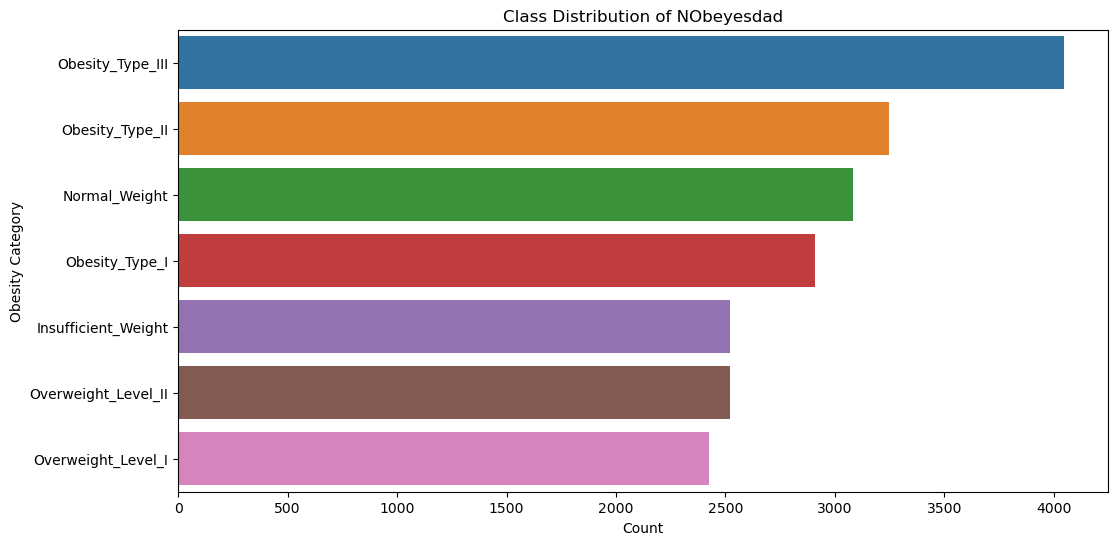

In [4]:
# Step 4: Visualize class distribution
plt.figure(figsize=(12,6))
sns.countplot(y=train["NObeyesdad"], order=train["NObeyesdad"].value_counts().index)
plt.title("Class Distribution of NObeyesdad")
plt.xlabel("Count")
plt.ylabel("Obesity Category")
plt.show()


Step 5 — Numeric Feature Distributions

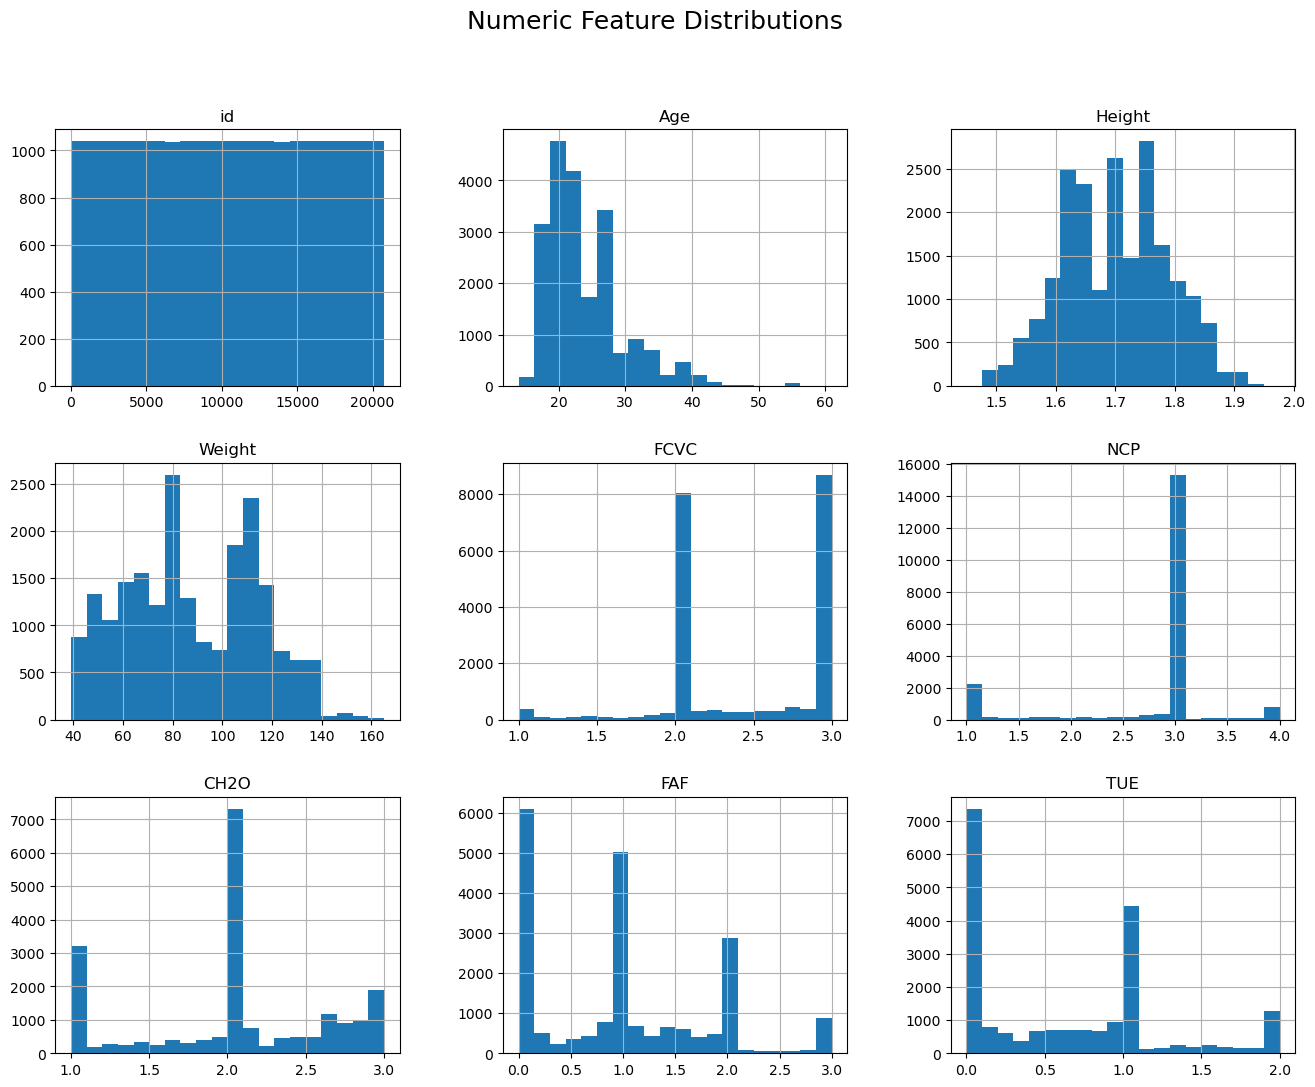

In [5]:
# Step 5: Histograms of numeric features
numeric_features = train.select_dtypes(include=["int64", "float64"]).columns.tolist()
train[numeric_features].hist(figsize=(16,12), bins=20)
plt.suptitle("Numeric Feature Distributions", fontsize=18)
plt.show()


Step 6 — Correlation Heatmap

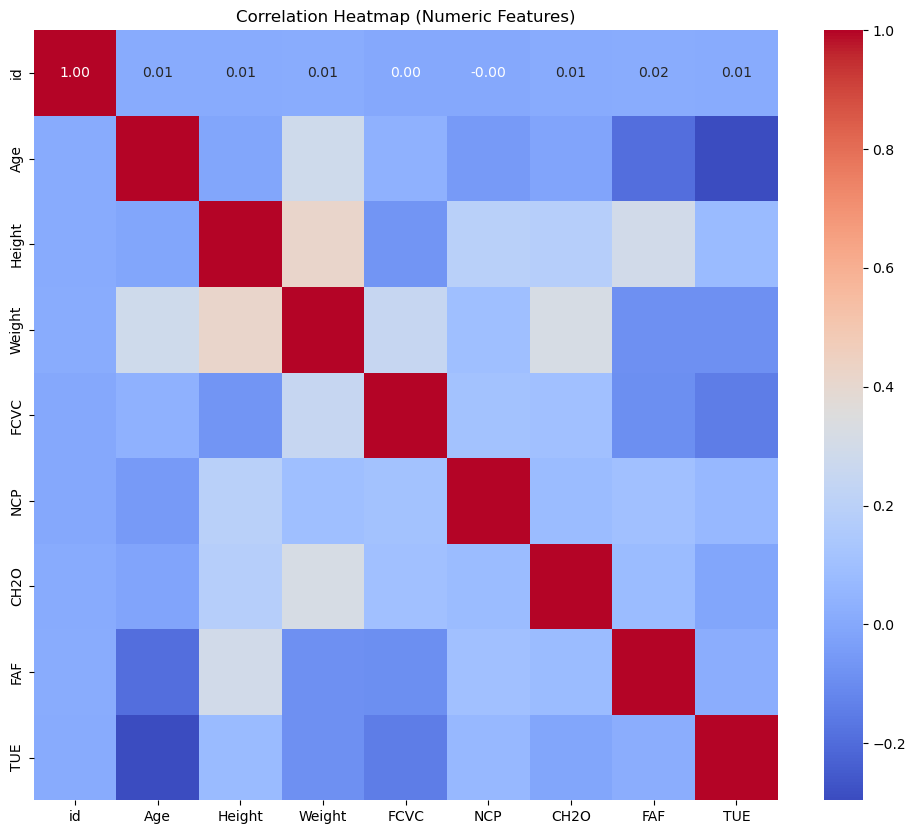

In [6]:
# Step 6: Correlation heatmap
plt.figure(figsize=(12,10))
sns.heatmap(train[numeric_features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()


Step 7 — Boxplots by Obesity Category

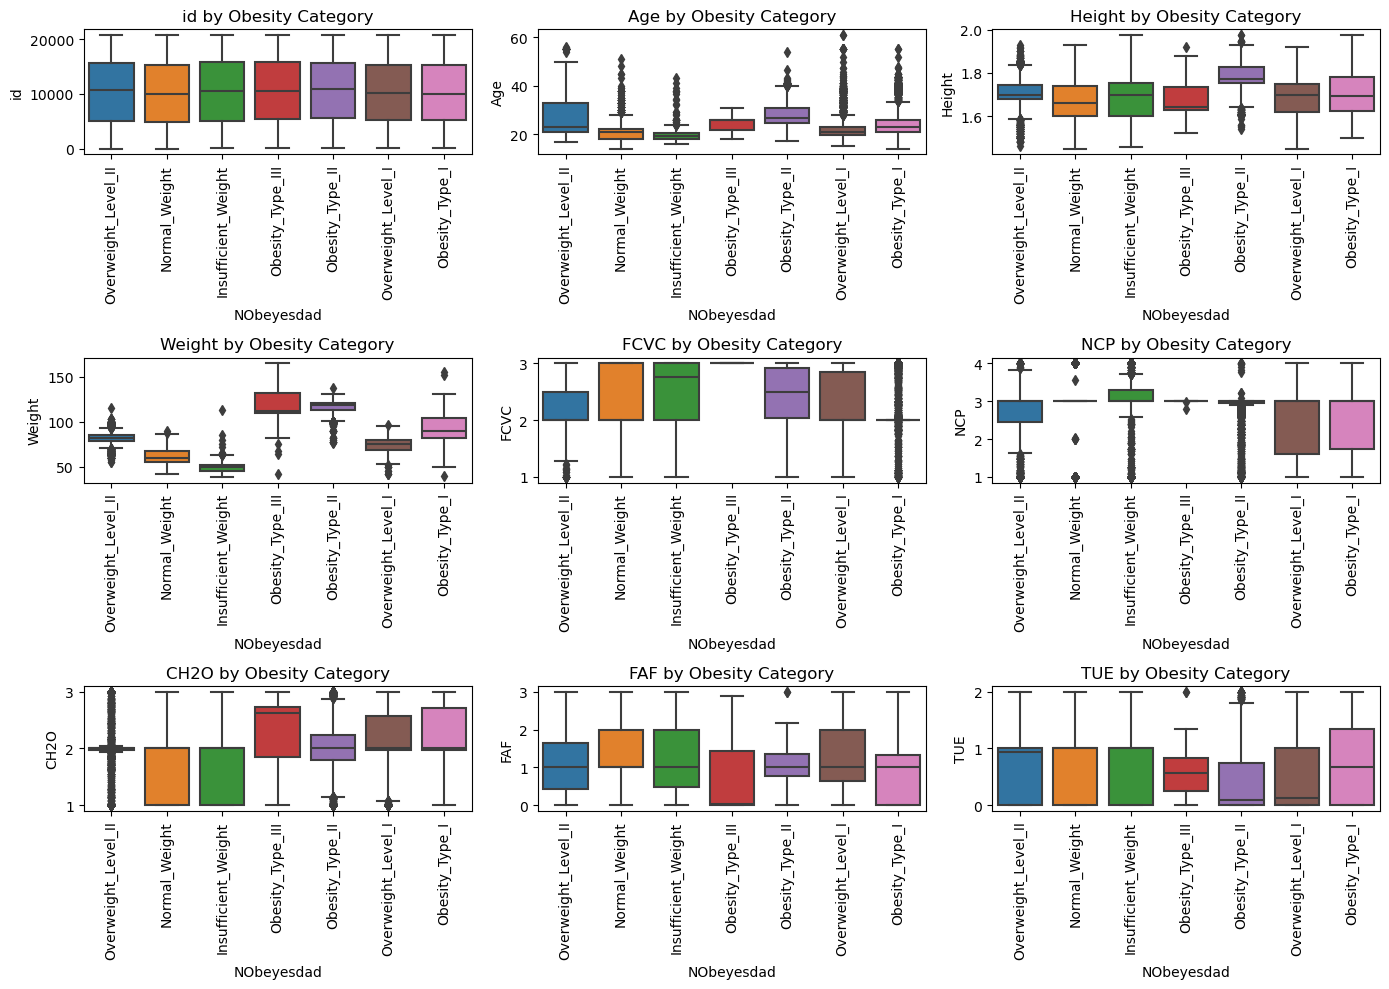

In [7]:
# Step 7: Boxplots by obesity category
plt.figure(figsize=(14,10))
for i, col in enumerate(numeric_features):
    plt.subplot(3, 3, i+1)
    sns.boxplot(data=train, x="NObeyesdad", y=col)
    plt.xticks(rotation=90)
    plt.title(f"{col} by Obesity Category")
plt.tight_layout()
plt.show()


Step 8 — Countplots for Categorical Features

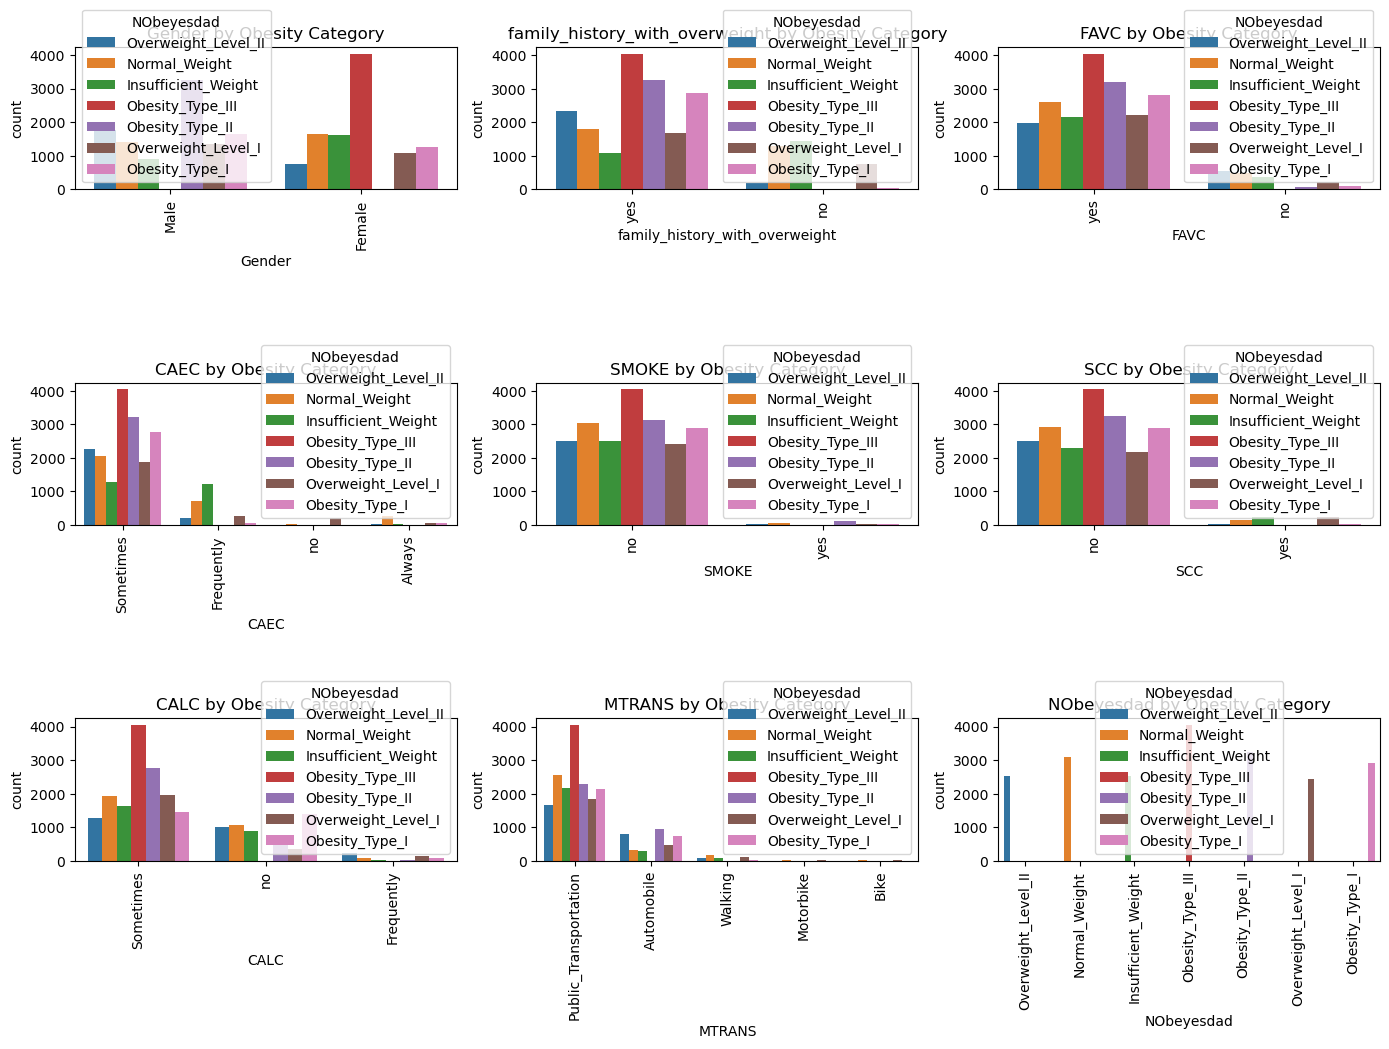

In [8]:
# Step 8: Countplots for categorical features
categorical_features = train.select_dtypes(include=["object"]).columns.tolist()

plt.figure(figsize=(14,12))
for i, col in enumerate(categorical_features):
    plt.subplot(4, 3, i+1)
    sns.countplot(data=train, x=col, hue="NObeyesdad")
    plt.xticks(rotation=90)
    plt.title(f"{col} by Obesity Category")
plt.tight_layout()
plt.show()


Step 9 – Separate features and target

In [9]:
# Step 9: Define X and y
target_col = "NObeyesdad"

X = train.drop(columns=[target_col])
y = train[target_col]

# Drop id from features (not useful for prediction)
if "id" in X.columns:
    X = X.drop(columns=["id"])

# For test set, drop id but keep it separately for submission
test_ids = test["id"] if "id" in test.columns else None
X_test = test.drop(columns=["id"]) if "id" in test.columns else test


Step 10 – Identify numeric and categorical columns

In [10]:
# Step 10: Identify column types
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric:", numeric_features)
print("Categorical:", categorical_features)


Numeric: ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
Categorical: ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']


Step 11 – Build preprocessing + logistic regression pipeline

In [11]:
# Step 11: Preprocessing and model pipeline

numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

log_reg = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=1000,
    n_jobs=-1
)

log_reg_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", log_reg)
    ]
)


Step 12 – Train/validation split and fit model

In [12]:
# Step 12: Train/validation split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Fit pipeline
log_reg_pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Height', 'Weight',
                                                   'FCVC', 'NCP', 'CH2O', 'FAF',
                                                   'TUE']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender',
                                                   'family_history_with_overweight',
                                                   'FAVC', 'CAEC', 'SMOKE',
                                                   'SCC', 'CALC',
                                                   'MTRANS'])])),
                ('model',
                 LogisticRegression(max_iter=1000, multi_class='multinomial',
                                    n_jobs=-1))])

Step 13 – Evaluate on validation set

In [13]:
# Step 13: Evaluate logistic regression
y_pred_valid = log_reg_pipeline.predict(X_valid)

print("Validation accuracy:", accuracy_score(y_valid, y_pred_valid))
print("\nClassification report:\n", classification_report(y_valid, y_pred_valid))
print("\nConfusion matrix:\n", confusion_matrix(y_valid, y_pred_valid))


Validation accuracy: 0.8680154142581888

Classification report:
                      precision    recall  f1-score   support

Insufficient_Weight       0.89      0.95      0.92       505
      Normal_Weight       0.87      0.82      0.84       617
     Obesity_Type_I       0.81      0.85      0.83       582
    Obesity_Type_II       0.93      0.96      0.95       650
   Obesity_Type_III       1.00      1.00      1.00       809
 Overweight_Level_I       0.75      0.71      0.73       485
Overweight_Level_II       0.73      0.70      0.72       504

           accuracy                           0.87      4152
          macro avg       0.85      0.85      0.85      4152
       weighted avg       0.87      0.87      0.87      4152


Confusion matrix:
 [[479  25   0   0   0   1   0]
 [ 59 504   2   0   0  42  10]
 [  1   0 492  36   4  11  38]
 [  0   0  22 625   0   0   3]
 [  0   0   0   1 807   1   0]
 [  1  46  15   0   0 342  81]
 [  0   3  79   8   0  59 355]]


Step 14 – Train on full training data

In [14]:
# Step 14: Retrain on full training data
log_reg_pipeline.fit(X, y)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Height', 'Weight',
                                                   'FCVC', 'NCP', 'CH2O', 'FAF',
                                                   'TUE']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender',
                                                   'family_history_with_overweight',
                                                   'FAVC', 'CAEC', 'SMOKE',
                                                   'SCC', 'CALC',
                                                   'MTRANS'])])),
                ('model',
                 LogisticRegression(max_iter=1000, multi_class='multinomial',
                                    n_jobs=-1))])

Step 15 – Predict on test set

In [15]:
# Step 15: Predict on Kaggle test data
test_preds_logreg = log_reg_pipeline.predict(X_test)

# Check shape
print(test_preds_logreg[:10])


['Obesity_Type_II' 'Overweight_Level_I' 'Obesity_Type_III'
 'Obesity_Type_I' 'Obesity_Type_III' 'Insufficient_Weight'
 'Insufficient_Weight' 'Normal_Weight' 'Overweight_Level_II'
 'Normal_Weight']


Step 16 – Build submission file (Logistic Regression)

In [16]:
# Step 16: Create submission DataFrame
submission_logreg = sample_submission.copy()

# Kaggle expects the target column name exactly as in sample_submission
target_submission_col = submission_logreg.columns[-1]  # usually "NObeyesdad"
submission_logreg[target_submission_col] = test_preds_logreg

# If sample_submission has an id column, keep it as is
submission_logreg.head()


,id,NObeyesdad
0,20758,Obesity_Type_II
1,20759,Overweight_Level_I
2,20760,Obesity_Type_III
3,20761,Obesity_Type_I
4,20762,Obesity_Type_III


Step 17 – Save CSV for first Kaggle submission

In [17]:
# Step 17: Save logistic regression submission
submission_logreg.to_csv("submission_logreg.csv", index=False)
